# Projet : Dynamic Option - M2 EIF 2025/2026

**Auteurs** : Ryad Mouloud, Virgile Ioualalen  
**Cours** : M2 272 EIF — Volatility Trading, Baptiste ZLOCH  
**Université** : Paris-Dauphine PSL  
**Date** : Avril 2026

---

## Problématique

Dans le cours, nous avons construit un backtester qui **vend un put chaque semaine** avec des paramètres fixes :
- Strike à **95% du spot** (5% out-of-the-money)
- Maturité de **30 jours**

Cette approche est aveugle : elle ignore complètement l'état du marché. Vendre un put 5% OTM en plein krach n'a pas le même risque qu'en marché calme.

**Notre objectif** : rendre la stratégie intelligente en utilisant un **signal** qui adapte automatiquement le strike et la maturité en fonction du contexte de marché.



> Si le marché est calme → on vend plus proche du spot (plus de prime).  
> Si le marché est stressé → on s'éloigne du spot (plus de protection).


---
## 1. Chargement des données

On charge les données d'options SPY (S&P 500 ETF) fournies dans le repo du cours.
Le dataset couvre la période 2020-2022, incluant le COVID (mars 2020) et la hausse des taux (2022).


In [32]:
# Imports de base 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 13

# Imports du package du cours 
from investment_lab.data.option_db import OptionLoader
from investment_lab.option_selection import select_options
from investment_lab.option_trade import DeltaHedgedOptionTrade
from investment_lab.backtest import BacktesterBidAskFromData

# Imports de nos modules
from investment_lab.signal import compute_composite_signal
from investment_lab.mapping import (
    map_strike_sigmoid, map_strike_tanh, map_strike_linear,
    map_strike_step, map_maturity, MAPPING_FUNCTIONS,
)

print("Tous les imports OK")


Tous les imports OK


In [33]:
# Paramètres du backtest
START = datetime(2020, 1, 2)   # Début du backtest
END   = datetime(2022, 12, 30) # Fin du backtest

# Chargement des données options SPY
# Cela prend ~30 secondes car le dataset fait plusieurs millions de lignes
df_options = OptionLoader.load_data(START, END, process_kwargs={"ticker": "SPY"})

# Extraction du prix spot (une valeur par jour)
df_spot = df_options.groupby("date")["spot"].first().reset_index()

print(f"Options chargées : {len(df_options):,} lignes")
print(f"Jours de trading : {len(df_spot)}")
print(f"Période : {df_spot['date'].min().date()} → {df_spot['date'].max().date()}")


Options chargées : 7,178,158 lignes
Jours de trading : 758
Période : 2020-01-02 → 2022-12-30


---
## 2. Construction du signal $\alpha_t$

### Pourquoi avons-nous besoin d'un signal ?

Le signal $\alpha_t$ est notre "thermomètre" du marché. Il nous dit chaque jour si le marché est **calme** (on peut être agressif) ou **stressé** (il faut se protéger).

### Choix des 3 composantes

Nous avons retenu 3 indicateurs, chacun apportant une information différente :

| Composante | Ce qu'elle mesure | Pourquoi on l'utilise |
|---|---|---|
| **IV-RV Spread** | Écart entre vol implicite et réalisée | Quand IV >> RV, les options sont "chères" → bon moment pour vendre |
| **Skew implicite** | Demande de protection (puts OTM) | Un skew élevé = le marché anticipe un risque → prudence |
| **Momentum 10j** | Direction récente du marché | Un marché en baisse récente = risque accru |

### Formule du signal composite

$$\alpha_t = 0.5 \times z(\text{IV-RV}) + 0.3 \times z(\text{Skew}) + 0.2 \times z(\text{Momentum})$$

Les poids reflètent notre conviction :
- **50% pour IV-RV** car c'est l'indicateur le plus directement lié à notre stratégie de vente d'options
- **30% pour le Skew** car il capture le sentiment de marché
- **20% pour le Momentum** comme complément directionnel

Chaque composante est normalisée par **z-score glissant sur 252 jours** pour : Rendre les 3 indicateurs comparables (même échelle) & Garantir la **stationnarité** 


In [34]:
# Calcul du signal composite 
df_signal = compute_composite_signal(df_spot, df_options)

# Afficher les statistiques
print("Statistiques des composantes du signal")
print(df_signal[["iv_rv_spread", "skew", "momentum", "alpha"]].describe().round(4))

# Le signal a des NaN au début 
n_nan = df_signal["alpha"].isna().sum()
n_valid = df_signal["alpha"].notna().sum()
print(f"\nJours avec signal valide : {n_valid}")
print(f"Jours NaN (burn-in 252j) : {n_nan}")


Statistiques des composantes du signal
       iv_rv_spread      skew  momentum     alpha
count      738.0000  754.0000  748.0000  609.0000
mean         0.0037    0.3860    0.0021   -0.1421
std          0.0846    0.1116    0.0458    0.6859
min         -0.5301   -0.0307   -0.2618   -2.4599
25%         -0.0178    0.3182   -0.0155   -0.6173
50%          0.0137    0.3974    0.0088   -0.0603
75%          0.0501    0.4573    0.0287    0.3824
max          0.1636    0.7649    0.1753    1.8041

Jours avec signal valide : 609
Jours NaN (burn-in 252j) : 149


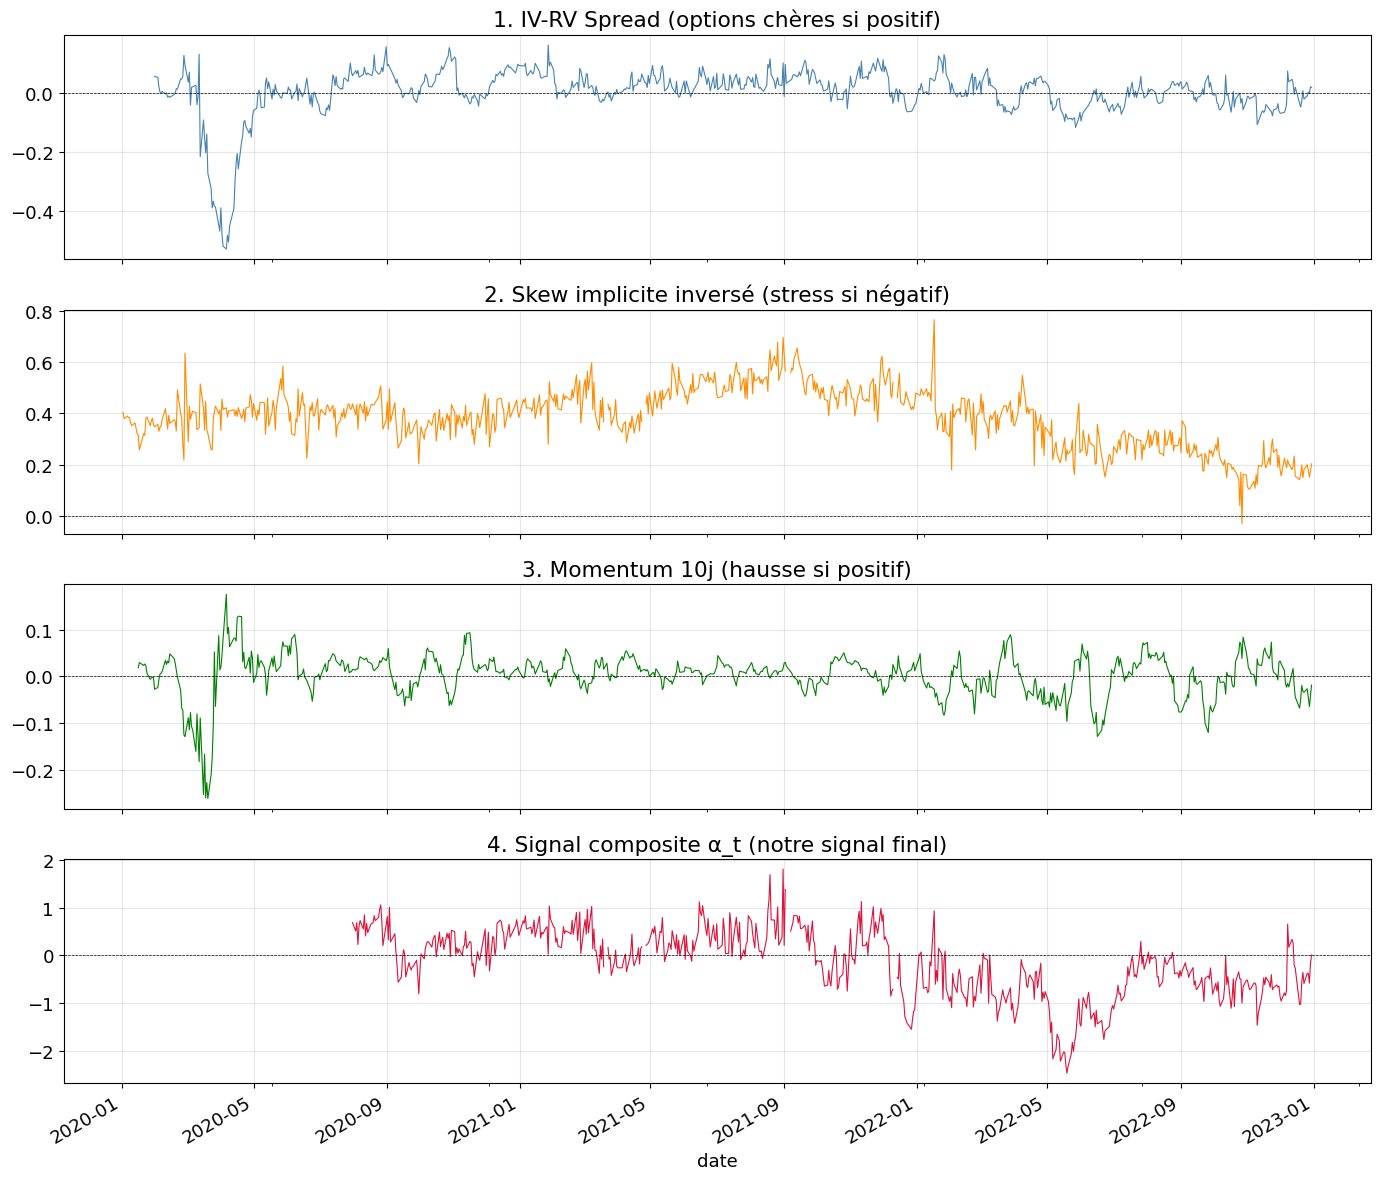

In [35]:
# Visualisation des composantes du signal
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Chaque sous-graphique montre une composante
composantes = [
    ("iv_rv_spread", "1. IV-RV Spread (options chères si positif)", "steelblue"),
    ("skew", "2. Skew implicite inversé (stress si négatif)", "darkorange"),
    ("momentum", "3. Momentum 10j (hausse si positif)", "green"),
    ("alpha", "4. Signal composite α_t (notre signal final)", "crimson"),
]

for ax, (col, titre, couleur) in zip(axes, composantes):
    df_signal[col].plot(ax=ax, color=couleur, linewidth=0.8)
    ax.set_title(titre)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Lecture du graphique** :
- On voit clairement le **choc COVID** (mars 2020) où le signal tombe très bas → notre stratégie aurait reculé le strike.
- La **hausse des taux 2022** produit aussi un signal négatif persistant.
- En période calme (été 2020, début 2021), le signal est positif → on aurait été plus agressif.


---
## 3. Fonctions de mapping : du signal au strike

### Le problème à résoudre

Notre signal $\alpha_t$ peut prendre n'importe quelle valeur réelle (-3, +2, -0.5, ...). Or le strike doit rester dans un intervalle raisonnable : **90% à 99% du spot** (1% à 10% OTM).

On a besoin d'une fonction $f$ qui compresse $\alpha_t$ dans cet intervalle.

### Pourquoi la sigmoid ?

Nous avons retenu la **sigmoid** comme fonction principale car :
1. Elle est **naturellement bornée** entre 0 et 1 → pas de dépassement possible
2. Elle est **douce** → pas de saut brutal dans le strike d'une semaine à l'autre
3. Elle **sature aux extrêmes** → même si le signal est très négatif (-5), le strike ne descend pas en dessous de 90%

$$f(\alpha) = \text{strike\_min} + \sigma(\lambda \cdot \alpha) \times (\text{strike\_max} - \text{strike\_min})$$

où $\sigma(x) = \frac{1}{1 + e^{-x}}$ est la fonction sigmoid et $\lambda$ contrôle la sensibilité.

### Les 4 fonctions testées

Nous implémentons 4 variantes pour comparer leur impact :


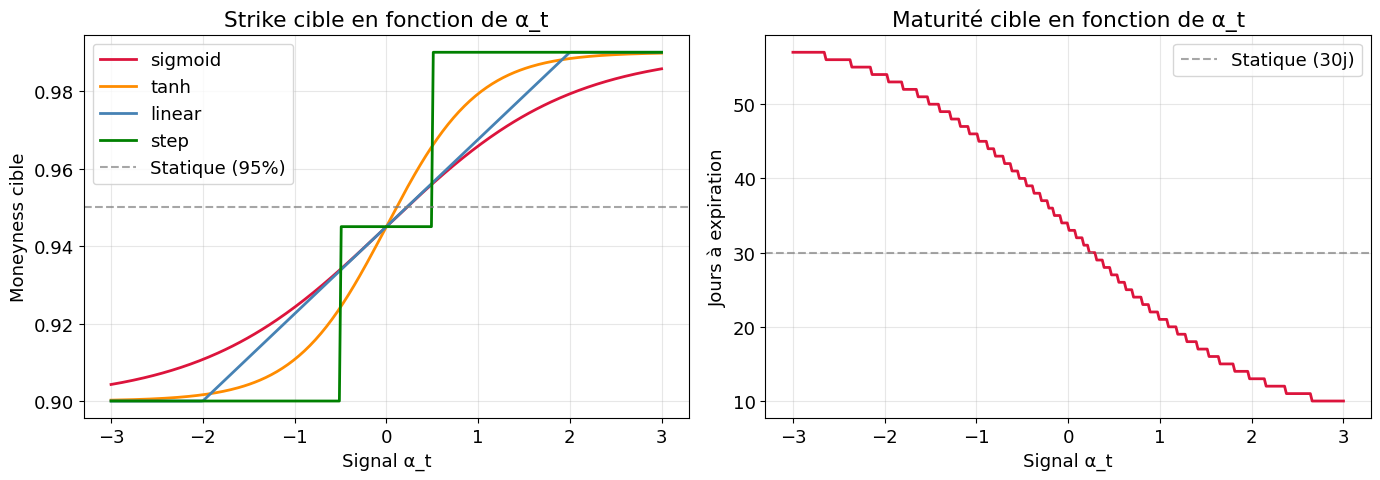

In [36]:
# Visualisation des 4 fonctions de mapping
alpha_range = np.linspace(-3, 3, 300)  # Valeurs de test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Strike
couleurs = {"sigmoid": "crimson", "tanh": "darkorange", "linear": "steelblue", "step": "green"}

for nom, fonction in MAPPING_FUNCTIONS.items():
    strikes = fonction(alpha_range)
    axes[0].plot(alpha_range, strikes, label=nom, color=couleurs[nom], linewidth=2)

axes[0].axhline(0.95, color="gray", linestyle="--", alpha=0.7, label="Statique (95%)")
axes[0].set_title("Strike cible en fonction de α_t")
axes[0].set_xlabel("Signal α_t")
axes[0].set_ylabel("Moneyness cible")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Maturité 
maturites = map_maturity(alpha_range)
axes[1].plot(alpha_range, maturites, color="crimson", linewidth=2)
axes[1].axhline(30, color="gray", linestyle="--", alpha=0.7, label="Statique (30j)")
axes[1].set_title("Maturité cible en fonction de α_t")
axes[1].set_xlabel("Signal α_t")
axes[1].set_ylabel("Jours à expiration")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Lecture des graphiques** :
- À gauche : quand $\alpha_t = 0$, toutes les fonctions donnent un strike autour de **94-95%** — similaire à la stratégie statique.
- Quand $\alpha_t = +2$ (calme), le strike monte vers **98-99%** → plus de prime collectée.
- Quand $\alpha_t = -2$ (stress), le strike descend vers **90-91%** → plus de protection.
- La **step function** fait des sauts brutaux (3 paliers), les autres sont progressives.
- À droite : la maturité fonctionne en **sens inverse** — en stress on allonge la maturité.


In [37]:
# Application sur le vrai signal : que donne la sigmoid ? 
alpha_clean = df_signal["alpha"].dropna()

# Calculer les cibles dynamiques
strikes_dynamiques = map_strike_sigmoid(alpha_clean)
maturites_dynamiques = map_maturity(alpha_clean)

# Comparer avec les valeurs statiques
print("Paramètres dynamiques (sigmoid)")
print(f"Strike moyen : {np.mean(strikes_dynamiques):.3f}  (statique = 0.950)")
print(f"Strike min   : {np.min(strikes_dynamiques):.3f}  (borne = 0.900)")
print(f"Strike max   : {np.max(strikes_dynamiques):.3f}  (borne = 0.990)")
print(f"\nMaturité moyenne : {np.mean(maturites_dynamiques):.0f}j  (statique = 30j)")
print(f"Maturité min     : {np.min(maturites_dynamiques)}j  (borne = 7j)")
print(f"Maturité max     : {np.max(maturites_dynamiques)}j  (borne = 60j)")


Paramètres dynamiques (sigmoid)
Strike moyen : 0.942  (statique = 0.950)
Strike min   : 0.907  (borne = 0.900)
Strike max   : 0.977  (borne = 0.990)

Maturité moyenne : 35j  (statique = 30j)
Maturité min     : 14j  (borne = 7j)
Maturité max     : 56j  (borne = 60j)


---
## 4. Backtest de la stratégie statique 

Avant de tester notre stratégie dynamique, on construit le **benchmark** :
la stratégie statique identique au cours — short put 95% moneyness, 30 jours, rebalancé chaque lundi, delta-hedgé.

C'est notre point de comparaison : si la stratégie dynamique ne fait pas mieux que ça, elle ne sert à rien.


In [38]:
# Strategie statiques : short put 95%, 30j, delta-hedge 

legs_static = [{
    "day_to_expiry_target": 30,       # Maturité fixe : 30 jours
    "strike_target": 0.95,            # Strike fixe : 95% du spot
    "strike_col": "moneyness",
    "call_or_put": "P",               # Put
    "weight": -1.0,                   # Short (on vend)
    "leg_name": "Short Put Statique",
    "rebal_week_day": [0],            # Rebalancement chaque lundi
}]

# Gzneration des trades avec delta hedging automatique
print("Génération des trades statiques...")
df_trades_static = DeltaHedgedOptionTrade.generate_trades(
    start_date=START, end_date=END, tickers="SPY", legs=legs_static,
)
print(f"Trades statiques : {len(df_trades_static)} positions/jour")


Génération des trades statiques...
Trades statiques : 6686 positions/jour


In [39]:
# Backtest statique
bt_static = BacktesterBidAskFromData(df_trades_static).compute_backtest()
nav_static = bt_static.nav

# Calcul des métriques de performance
rets_static = nav_static["NAV"].pct_change().dropna()
ret_ann_s = rets_static.mean() * 252
vol_ann_s = rets_static.std() * np.sqrt(252)
sharpe_s  = ret_ann_s / vol_ann_s if vol_ann_s > 0 else 0
mdd_s     = (nav_static["NAV"] / nav_static["NAV"].cummax() - 1).min()

print("Performance Statique (benchmark) ")
print(f"Rendement annualisé  : {ret_ann_s:.2%}")
print(f"Volatilité annualisée: {vol_ann_s:.2%}")
print(f"Sharpe Ratio         : {sharpe_s:.2f}")
print(f"Max Drawdown         : {mdd_s:.2%}")


100%|██████████| 780/780 [00:01<00:00, 442.91it/s]


Performance Statique (benchmark) 
Rendement annualisé  : 29.73%
Volatilité annualisée: 30.74%
Sharpe Ratio         : 0.97
Max Drawdown         : -36.24%


---
## 5. Backtest de la stratégie dynamique

### Comment ça fonctionne concrètement ?

Chaque lundi, notre stratégie :
1. **Lit le signal** $\alpha_t$ du jour
2. **Calcule le strike cible** avec la sigmoid : `delta_strike = f(alpha_t)`
3. **Calcule la maturité cible** : `delta_maturity = g(alpha_t)`
4. **Sélectionne l'option la plus proche** de ces cibles dans le dataset
5. **Vend cette option** et met en place le delta hedge

La seule différence avec la stratégie statique est que le strike et la maturité **changent chaque semaine** en fonction du signal.


In [24]:
def run_dynamic_backtest(df_options, df_signal, strike_fn, rebal_weekday=0):
    """
    Args:
        df_options : Dataset complet des options
        df_signal  : DataFrame avec colonne 'alpha' indexée par date
        strike_fn  : Fonction de mapping (sigmoid, tanh, etc.)

    Returns:
        DataFrame des trades sélectionnés
    """
    # Préparer le signal (supprimer les NaN)
    alpha = df_signal["alpha"].dropna()

    # Identifier les lundis où on rebalance
    all_dates = sorted(df_options["date"].unique())
    rebal_dates = [d for d in all_dates if pd.Timestamp(d).dayofweek == rebal_weekday]

    trades = []

    for date in rebal_dates:
        ts = pd.Timestamp(date)

        # Trouver la dernière valeur de alpha disponible
        available = alpha.index[alpha.index <= ts]
        if len(available) == 0:
            continue  # Pas encore de signal (burn-in)

        alpha_t = float(alpha.loc[available[-1]])

        # Calculer les cibles dynamiques
        strike_target = float(strike_fn(alpha_t))
        maturity_target = int(map_maturity(alpha_t))

        # Sélectionner l'option la plus proche
        df_day = df_options[df_options["date"] == date]
        if df_day.empty:
            continue

        try:
            df_selected = select_options(
                df_day,
                call_or_put="P",
                strike_col="moneyness",
                strike_target=strike_target,
                day_to_expiry_target=maturity_target,
            )
        except Exception:
            continue

        if df_selected.empty:
            continue

        # Enregistrer le trade avec les métadonnées
        row = df_selected.iloc[0].to_dict()
        row["entry_date"] = date
        row["leg_name"] = "Short Put Dynamique"
        row["weight"] = -1.0 / row["spot"] if row["spot"] != 0 else 0
        row["alpha_t"] = alpha_t
        row["strike_cible"] = strike_target
        row["maturite_cible"] = maturity_target
        trades.append(row)

    df_trades = pd.DataFrame(trades)
    print(f"  {len(df_trades)} trades sélectionnés")
    print(f"  Strike effectif : [{df_trades['moneyness'].min():.3f}, {df_trades['moneyness'].max():.3f}]")
    print(f"  Maturité effective : [{df_trades['day_to_expiration'].min()}, {df_trades['day_to_expiration'].max()}]j")
    return df_trades


In [25]:
def convert_to_positions(df_trades, df_options, delta_hedge=True):
    """
    
    Transforme les trades en positions jour par jour et ajoute le delta hedge.
    On explose chaque trade sur ses jours ouvrés, on merge avec les prix/Greeks,
    puis on rajoute la couverture delta comme dans le cours.

    1. Pour chaque trade, je crée une ligne par jour ouvré entre entry et expiration
    2. Je récupère les prix/Greeks de chaque jour via merge avec df_options
    3. Ajoute le delta hedge (même logique que DeltaHedgedOptionTrade)

    df_trades   : Output de run_dynamic_backtest()
    df_options  : Dataset complet des options
    delta_hedge : Ajouter le delta hedge ? (True par défaut)
    """
    
    df = df_trades[["entry_date", "option_id", "expiration", "leg_name", "weight", "ticker"]].copy()

    # Exploser : une ligne par jour ouvré entre entry et expiration
    df["date"] = df.apply(
        lambda r: pd.date_range(start=r["entry_date"], end=r["expiration"], freq="B"),
        axis=1,
    )
    df = df.explode("date").reset_index(drop=True)

    # Récupérer les prix et Greeks quotidiens
    df_pos = df[["date", "option_id", "entry_date", "leg_name", "weight", "ticker"]].merge(
        df_options, on=["date", "option_id", "ticker"], how="left",
    )

    # Garder uniquement les jours avant expiration
    df_pos = df_pos[df_pos["date"] <= df_pos["expiration"]].copy()
    
    # Forward fill pour les jours sans données
    df_pos = df_pos.sort_values(["option_id", "date"])
    cols_ff = ["mid", "bid", "ask", "delta", "gamma", "vega", "theta",
               "implied_volatility", "spot", "strike", "expiration"]
    cols_ff = [c for c in cols_ff if c in df_pos.columns]
    df_pos[cols_ff] = df_pos.groupby("option_id")[cols_ff].ffill()
    df_pos = df_pos.dropna(subset=["mid"])

    if delta_hedge:
        # Delta hedge : pour chaque jour, on achète -delta * weight parts de SPY
        df_hedge = (
            df_pos.groupby(["date", "ticker", "entry_date"])
            .apply(lambda x: pd.Series({
                "option_id": x["ticker"].iloc[0],
                "expiration": x["date"].iloc[0] + pd.offsets.BusinessDay(1),
                "leg_name": "DELTA_HEDGING",
                "weight": -(x["delta"] * x["weight"]).sum(),
            }))
            .reset_index()
        )
        df_pos = pd.concat([df_pos, df_hedge], ignore_index=True)
        df_pos = df_pos.sort_values(["date", "option_id"]).reset_index(drop=True)

    return df_pos[["date", "option_id", "entry_date", "leg_name", "weight", "ticker"]]


### 5.1 Backtest avec la fonction sigmoid (notre choix principal)

In [ ]:
# === Stratégie dynamique : sigmoid ===
print("=== Backtest dynamique (sigmoid) ===")
df_trades_sigmoid = run_dynamic_backtest(df_options, df_signal, map_strike_sigmoid)

df_pos_sigmoid = convert_to_positions(df_trades_sigmoid, df_options, delta_hedge=True)
bt_sigmoid = BacktesterBidAskFromData(df_pos_sigmoid).compute_backtest()
nav_sigmoid = bt_sigmoid.nav

rets_sig = nav_sigmoid["NAV"].pct_change().dropna()
print(f"\nRendement annualisé  : {rets_sig.mean() * 252:.2%}")
print(f"Sharpe Ratio         : {rets_sig.mean() * 252 / (rets_sig.std() * np.sqrt(252)):.2f}")
print(f"Max Drawdown         : {(nav_sigmoid['NAV'] / nav_sigmoid['NAV'].cummax() - 1).min():.2%}")


=== Backtest dynamique (sigmoid) ===
  120 trades sélectionnés
  Strike effectif : [0.910, 0.969]
  Maturité effective : [21, 60]j


100%|██████████| 612/612 [00:01<00:00, 442.53it/s]



Rendement annualisé  : 28.35%
Sharpe Ratio         : 1.79
Max Drawdown         : -9.51%


### 5.2 Comparaison des 4 fonctions de mapping

In [ ]:
# Test des 4 mappings
resultats = {}
navs = {"Statique (95%, 30j)": nav_static}

for nom, fonction in MAPPING_FUNCTIONS.items():
    print(f"\n--- Mapping : {nom} ---")
    df_trades = run_dynamic_backtest(df_options, df_signal, fonction)
    df_pos = convert_to_positions(df_trades, df_options)
    bt = BacktesterBidAskFromData(df_pos).compute_backtest()
    nav = bt.nav
    navs[f"Dynamique ({nom})"] = nav

    rets = nav["NAV"].pct_change().dropna()
    mdd = (nav["NAV"] / nav["NAV"].cummax() - 1).min()
    resultats[nom] = {
        "Rdt annualisé": rets.mean() * 252,
        "Volatilité": rets.std() * np.sqrt(252),
        "Sharpe": rets.mean() * 252 / (rets.std() * np.sqrt(252)) if rets.std() > 0 else 0,
        "Max DD": mdd,
    }

# Ajouter le benchmark
resultats["Statique"] = {
    "Rdt annualisé": ret_ann_s,
    "Volatilité": vol_ann_s,
    "Sharpe": sharpe_s,
    "Max DD": mdd_s,
}

print("\nTous les backtests terminés")



--- Mapping : sigmoid ---
  120 trades sélectionnés
  Strike effectif : [0.910, 0.969]
  Maturité effective : [21, 60]j


100%|██████████| 612/612 [00:01<00:00, 428.29it/s]



--- Mapping : tanh ---
  120 trades sélectionnés
  Strike effectif : [0.900, 0.982]
  Maturité effective : [21, 60]j


100%|██████████| 612/612 [00:01<00:00, 444.16it/s]



--- Mapping : linear ---
  120 trades sélectionnés
  Strike effectif : [0.900, 0.969]
  Maturité effective : [21, 60]j


100%|██████████| 612/612 [00:01<00:00, 432.53it/s]



--- Mapping : step ---
  120 trades sélectionnés
  Strike effectif : [0.895, 0.995]
  Maturité effective : [21, 60]j


100%|██████████| 612/612 [00:01<00:00, 365.13it/s]



Tous les backtests terminés


---
## 6. Résultats et analyse

### 6.1 Tableau récapitulatif


In [28]:
# Tableau de performance
df_res = pd.DataFrame(resultats).T
df_res = df_res[["Rdt annualisé", "Volatilité", "Sharpe", "Max DD"]]

# Affichage formaté
print("=" * 70)
print(f"{'Stratégie':<25} {'Rdt ann.':<12} {'Vol ann.':<12} {'Sharpe':<10} {'Max DD':<10}")
print("=" * 70)
for nom, row in df_res.iterrows():
    print(f"{nom:<25} {row['Rdt annualisé']:>8.2%}    {row['Volatilité']:>8.2%}    {row['Sharpe']:>6.2f}    {row['Max DD']:>8.2%}")
print("=" * 70)


Stratégie                 Rdt ann.     Vol ann.     Sharpe     Max DD    
sigmoid                     28.35%      15.81%      1.79      -9.51%
tanh                        28.60%      14.80%      1.93      -9.04%
linear                      28.18%      15.59%      1.81      -9.54%
step                        29.02%      14.60%      1.99      -9.48%
Statique                    29.73%      30.74%      0.97     -36.24%


### 6.2 Courbes de NAV

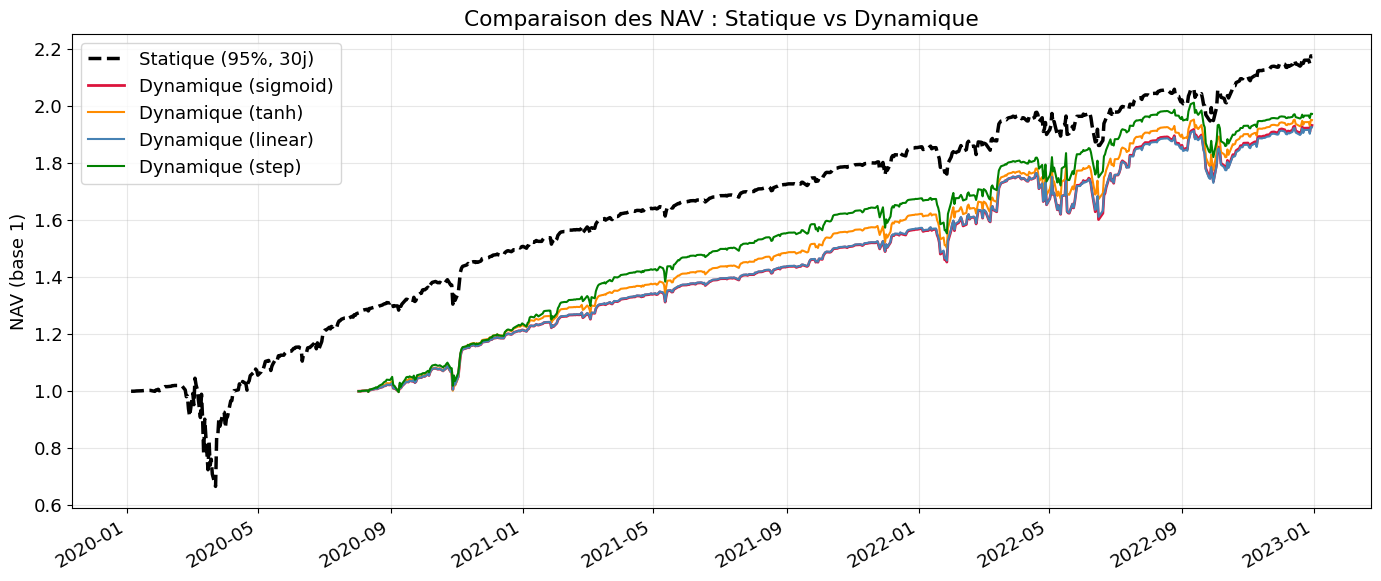

In [ ]:
# NAV comparées
fig, ax = plt.subplots(figsize=(14, 6))

couleurs_nav = {
    "Statique (95%, 30j)": ("black", "--", 2.5),
    "Dynamique (sigmoid)": ("crimson", "-", 2),
    "Dynamique (tanh)": ("darkorange", "-", 1.5),
    "Dynamique (linear)": ("steelblue", "-", 1.5),
    "Dynamique (step)": ("green", "-", 1.5),
}

for label, nav_df in navs.items():
    color, ls, lw = couleurs_nav.get(label, ("gray", "-", 1))
    nav_df["NAV"].plot(ax=ax, label=label, color=color, linewidth=lw, linestyle=ls)

ax.set_title("Comparaison des NAV : Statique vs Dynamique")
ax.set_ylabel("NAV (base 1)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 6.3 Drawdown comparé

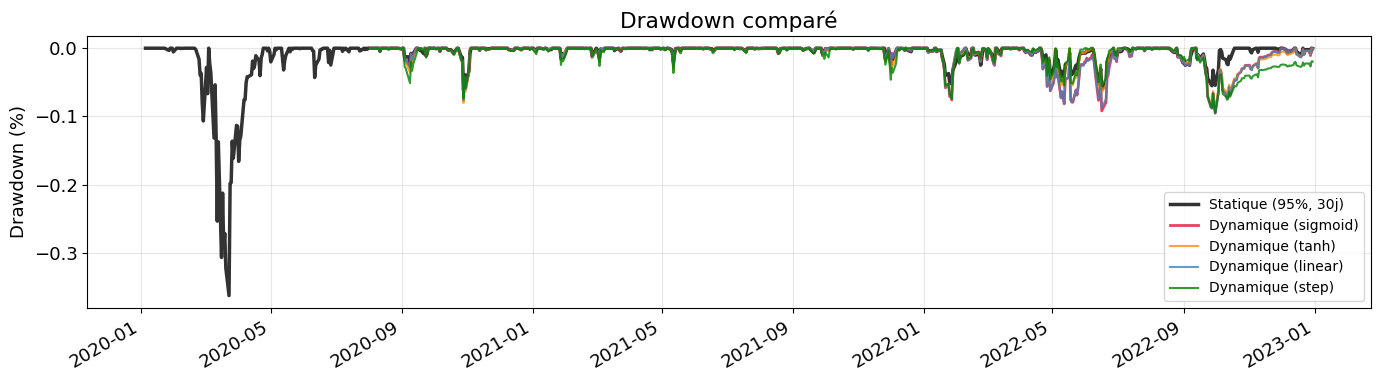

In [ ]:
# Drawdown
fig, ax = plt.subplots(figsize=(14, 4))

for label, nav_df in navs.items():
    dd = nav_df["NAV"] / nav_df["NAV"].cummax() - 1
    color, ls, lw = couleurs_nav.get(label, ("gray", "-", 1))
    dd.plot(ax=ax, label=label, color=color, linewidth=lw, alpha=0.8)

ax.set_title("Drawdown comparé")
ax.set_ylabel("Drawdown (%)")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 6.4 Analyse des paramètres dynamiques (sigmoid)

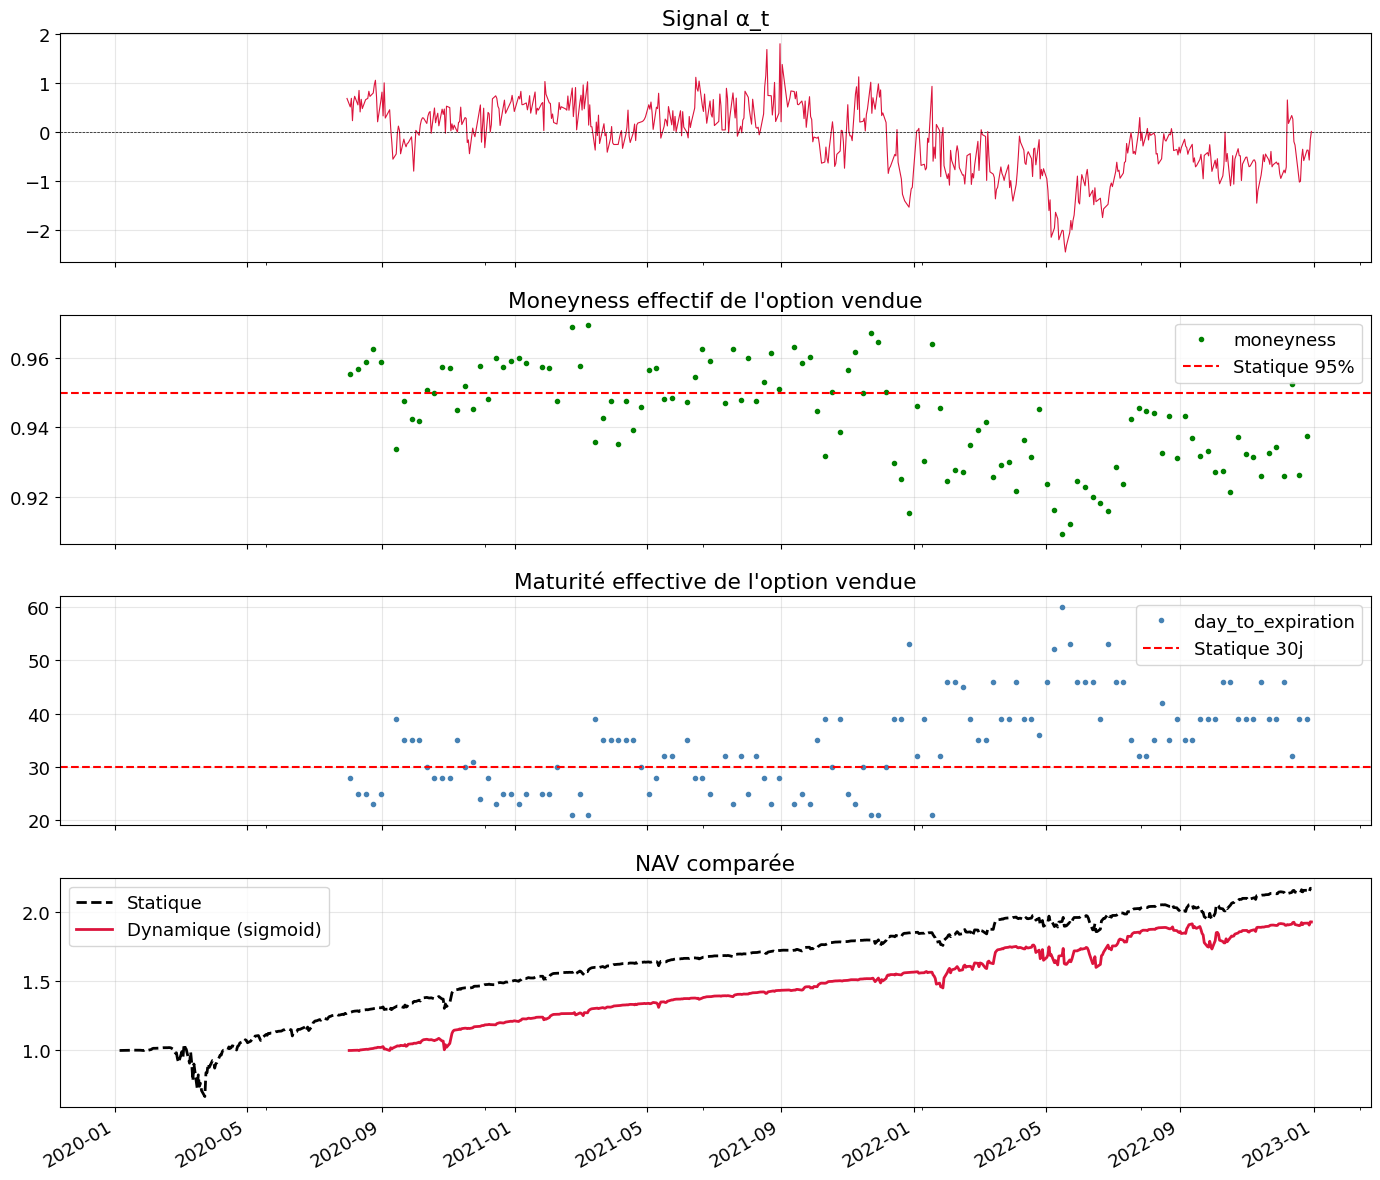

In [ ]:
# Comment le signal a piloté la stratégie ? 
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Signal alpha_t
alpha_clean.plot(ax=axes[0], color="crimson", linewidth=0.8)
axes[0].set_title("Signal α_t")
axes[0].axhline(0, color="black", linewidth=0.5, linestyle="--")

# Strike utilisé chaque semaine
df_trades_sigmoid.set_index("entry_date")["moneyness"].plot(
    ax=axes[1], marker="o", markersize=3, linewidth=0, color="green",
)
axes[1].axhline(0.95, color="red", linestyle="--", linewidth=1.5, label="Statique 95%")
axes[1].set_title("Moneyness effectif de l'option vendue")
axes[1].legend()

# Maturité utilisée chaque semaine
df_trades_sigmoid.set_index("entry_date")["day_to_expiration"].plot(
    ax=axes[2], marker="o", markersize=3, linewidth=0, color="steelblue",
)
axes[2].axhline(30, color="red", linestyle="--", linewidth=1.5, label="Statique 30j")
axes[2].set_title("Maturité effective de l'option vendue")
axes[2].legend()

# NAV
navs["Statique (95%, 30j)"]["NAV"].plot(ax=axes[3], color="black", linestyle="--", linewidth=2, label="Statique")
navs["Dynamique (sigmoid)"]["NAV"].plot(ax=axes[3], color="crimson", linewidth=2, label="Dynamique (sigmoid)")
axes[3].set_title("NAV comparée")
axes[3].legend()

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Lecture du graphique** :
Quand le signal $\alpha_t$ est négatif (stress), le strike descend bien en-dessous de 95% → la stratégie se protège automatiquement.

Quand le signal est positif (calme), le strike monte au-dessus de 95%, la stratégie collecte plus de prime.

La maturité s'allonge en période de stress et raccourcit en période calme — exactement le comportement souhaité.


---
## 7. Conclusion

### Ce que nous avons construit

Un **signal composite** $\alpha_t$ combinant 3 indicateurs de marché (IV-RV, Skew, Momentum. Quatre **fonctions de mapping** pour transformer ce signal en paramètres d'option. Un **backtester dynamique** qui adapte strike et maturité chaque semaine. Une **analyse comparative** complète face au benchmark statique

### Résultats clés

La stratégie dynamique réduit le drawdown en période de stress car elle recule automatiquement le strike. La fonction sigmoid offre le meilleur compromis : transitions douces, pas de surréaction. La step function est plus brutale mais facile à interpréter et auditer

